# OCRP HR Conv Mechanics

This notebook is a focused analysis of the HR masked equivariant convolution used after OCRP in the standard `4x4` experiment.

Goals:
- explain exactly what the HR conv computes
- separate the TP branch from the residual path
- show why the branch is **not automatically a smoothing layer**
- inspect how the role of the HR conv evolves across training, especially around the bend near epoch 30


## Core Equations

For a feature image `x` on the HR lattice, `CosineMaskedEquivariantSpatialConv` does:

1. Extract a local patch around each HR pixel.
2. Compute cosine similarity between the center feature and each patch member.
3. Build masked spatial weights:
   - `base_w = softmax(spatial_logits)`
   - `mask = sigmoid(temp * (cos - thr))` for soft masking, or an indicator for hard masking
   - the center pixel is always forced into the mask
4. Renormalize the surviving weights and form the pooled neighborhood context
   - `neigh = sum_j w_j patch_j / sum_j w_j`
5. Apply a same-out equivariant tensor product with the center feature
   - `tp = TP(center, neigh)`
6. Add the residual path if enabled
   - `out = tp + beta * center`

So this layer is **not** a plain averaging filter. It is a learnable equivariant transform of `(center, neigh)` plus an optional weighted skip path.

That difference matters:
- a true smoother would be biased toward something like `center + alpha * (neigh - center)`
- this layer is biased toward `beta * center + TP(center, neigh)`

If the model can solve the task with a mostly-residual solution, it may never discover strong smoothing behavior unless the loss or parameterization makes that attractive.


In [9]:
from __future__ import annotations

import importlib
import inspect
import json
import sys
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Find repo root robustly whether the notebook is launched from repo root or ideas/
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'models' / 'SR_ocrp.py').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from training.config_utils import load_and_prepare_config
from training.data_loading import build_dataloader
from training.train_iso_embedding_sr_attn import _flatten_quat_chw_batch, _unpack_batch

print('Repo root:', REPO_ROOT)


Repo root: /data/home/umang/Materials/Reynolds-QSR_4x1


## Experiment Under Study

Default target:
- `experiments/IN718/iso_embedding_ocrp_01_4x4`

This notebook is written to analyze the standard `4x4` OCRP experiment with the HR conv stack enabled. It should still work on future checkpoints as long as the model class remains compatible.


In [10]:
EXP_DIR = REPO_ROOT / 'experiments' / 'IN718' / 'iso_embedding_ocrp_01_4x4'
CONFIG_PATH = EXP_DIR / 'config_new.json'
CHECKPOINT_DIR = EXP_DIR / 'checkpoints'
CHECKPOINT_LABELS = ['25', '30', '35', '40', '45', '50', 'best']
VAL_TAKE_FIRST = 4

cfg = load_and_prepare_config(CONFIG_PATH)
with open(CONFIG_PATH, 'r') as f:
    cfg_json = json.load(f)

print('Experiment:', EXP_DIR)
print('use_hr_conv1:', cfg_json.get('use_hr_conv1'))
print('hr_conv1_kernel_size:', cfg_json.get('hr_conv1_kernel_size'))
print('hr_conv1_residual_weight:', cfg_json.get('hr_conv1_residual_weight'))
print('use_hr_conv2:', cfg_json.get('use_hr_conv2'))
print('hr_conv2_kernel_size:', cfg_json.get('hr_conv2_kernel_size'))
print('hr_conv2_residual_weight:', cfg_json.get('hr_conv2_residual_weight'))
print('hr_conv_feature_mask_soft:', cfg_json.get('hr_conv_feature_mask_soft'))
print('hr_conv_feature_mask_cosine_threshold:', cfg_json.get('hr_conv_feature_mask_cosine_threshold', cfg_json.get('conv_feature_mask_cosine_threshold')))


Using symmetry group from config: Oh
Overridden config values:
  - dataset_root: /data/home/umang/Materials/Materials_data_mount/datasets/IN718 (default: )
  - epochs: 150 (default: 10)
  - batch_size: 8 (default: 4)
  - symmetry_group: Oh (default: O)
  - use_amp: True (default: False)
  - decoder_steps: 20 (default: 1)
  - decoder_lr: 0.03 (default: 0.05)
  - viz_every: 1 (default: 5)
  - num_workers: 8 (default: 0)
  - persistent_workers: True (default: False)
  - prefetch_factor: 4 (default: 2)
  - preload: True (default: False)
  - preload_torch: True (default: False)
  - cudnn_benchmark: True (default: False)
  - min_free_cuda_gb: 4.0 (default: 0.0)
  - model.type: iso_embedding_ocrp (default: iso_embedding_sr_attn)
Using existing symmetry files for Oh
Experiment: /data/home/umang/Materials/Reynolds-QSR_4x1/experiments/IN718/iso_embedding_ocrp_01_4x4
use_hr_conv1: True
hr_conv1_kernel_size: 7
hr_conv1_residual_weight: 0.3
use_hr_conv2: True
hr_conv2_kernel_size: 7
hr_conv2_residu

## Helper: Build the Exact Model Class from the Experiment Config

We instantiate the model the same way the trainer does, then load any checkpoint we want to inspect.


In [11]:
def build_model_from_cfg(cfg, device: str = 'cpu'):
    model_cfg = getattr(cfg, 'model', {}) or {}
    if isinstance(model_cfg, dict):
        model_module = model_cfg.get('model_module', 'models.SR_ocrp')
        model_class = model_cfg.get('model_class', 'IsoEmbeddingSROCRP')
    else:
        model_module = getattr(model_cfg, 'model_module', 'models.SR_ocrp')
        model_class = getattr(model_cfg, 'model_class', 'IsoEmbeddingSROCRP')
    Cls = getattr(importlib.import_module(model_module), model_class)
    sig = inspect.signature(Cls.__init__).parameters
    kwargs = {}
    for name in sig:
        if name == 'self':
            continue
        if name == 'device':
            kwargs[name] = device
        elif name == 'upsample_factor':
            kwargs[name] = getattr(cfg, 'upsample_factor', getattr(cfg, 'scale', 4))
        elif hasattr(cfg, name):
            kwargs[name] = getattr(cfg, name)
    model = Cls(**kwargs).to(device).eval()
    return model


def load_checkpoint_into_model(model, ckpt_path: Path):
    ckpt = torch.load(ckpt_path, map_location='cpu')
    model.load_state_dict(ckpt['model_state_dict'])
    return ckpt


model = build_model_from_cfg(cfg, device='cpu')
print(type(model).__name__)


IsoEmbeddingSROCRP


## Helper: Build a Small Validation Slice

We keep this intentionally small because the point is understanding the mechanics, not benchmarking the whole split.


In [12]:
val_loader = build_dataloader(
    dataset_root=cfg.dataset_root,
    split='Val',
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    preload=False,
    preload_torch=False,
    persistent_workers=False,
    prefetch_factor=2,
    take_first=VAL_TAKE_FIRST,
    return_lr_boundary_map=False,
)
val_batches = list(val_loader)
print('Val mini-slice size:', len(val_batches))


Val mini-slice size: 4


## Helper: Exact Branch Decomposition

This reconstructs the internals of `CosineMaskedEquivariantSpatialConv` directly from the layer state:
- pooled neighborhood context `neigh`
- TP branch `tp = TP(center, neigh)`
- residual branch `beta * center`

That lets us answer questions like:
- Is the final output mostly residual?
- Is the TP branch large or small?
- Is the pooled neighborhood actually different from the center?
- Is the TP branch additive or subtractive relative to the residual path?


In [13]:
def decompose_conv(conv, inp: torch.Tensor, img_shape: tuple[int, int]):
    bsz, n, cdim = inp.shape
    h, w = img_shape
    feat_img = inp.view(bsz, h, w, cdim).permute(0, 3, 1, 2).contiguous()
    patches = conv._extract_patches(feat_img)
    center = feat_img.unsqueeze(-1).unsqueeze(-1)

    dot = (patches * center).sum(dim=1)
    patch_norm = patches.pow(2).sum(dim=1).clamp_min(conv.eps).sqrt()
    center_norm = feat_img.pow(2).sum(dim=1).clamp_min(conv.eps).sqrt().unsqueeze(-1).unsqueeze(-1)
    cosine = (dot / (patch_norm * center_norm).clamp_min(conv.eps)).clamp(-1.0, 1.0)

    masked_w = conv._masked_spatial_weights(cosine)
    denom = masked_w.sum(dim=(-1, -2)).clamp_min(conv.eps)
    norm_w = masked_w / denom.unsqueeze(-1).unsqueeze(-1)
    neigh = (patches * masked_w.unsqueeze(1)).sum(dim=(-1, -2)) / denom.unsqueeze(1)

    feat_flat = inp.reshape(bsz * n, cdim)
    neigh_flat = neigh.permute(0, 2, 3, 1).reshape(bsz * n, cdim)
    tp = conv.tp(feat_flat, neigh_flat).reshape(bsz, n, conv.out_dim)

    if conv.residual_proj is None:
        resid = conv.residual_weight * inp
    else:
        resid = conv.residual_weight * conv.residual_proj(feat_flat).reshape(bsz, n, conv.out_dim)

    return {
        'tp': tp,
        'resid': resid,
        'neigh': neigh.permute(0, 2, 3, 1).reshape(bsz, n, cdim),
        'norm_w': norm_w,
    }


def mean_norm(x: torch.Tensor) -> float:
    return float(x.norm(dim=-1).mean().item())


def mean_cos(a: torch.Tensor, b: torch.Tensor) -> float:
    aa = a.reshape(-1, a.shape[-1])
    bb = b.reshape(-1, b.shape[-1])
    return float(F.cosine_similarity(aa, bb, dim=-1, eps=1e-8).mean().item())


## Helper: Analyze One Checkpoint

This computes:
- raw OCRP feature error to the HR target feature
- error after HR conv 1
- error after the full HR stack
- TP/residual branch norm ratios for HR conv 1 and HR conv 2
- how much the pooled neighborhood is still aligned with the input
- how much of the normalized spatial weight sits on the center pixel

Interpretation hints:
- `tp/resid << 1`: residual dominates the final direction
- `cos(neigh, input) ~ 1`: context pooling is mostly producing an almost-colinear vector
- `center_weight` small but `cos(neigh, input) ~ 1`: the layer is mixing neighbors, but they are so similar that the pooled direction barely changes


In [14]:
def analyze_checkpoint(model, ckpt_path: Path, val_batches):
    _ = load_checkpoint_into_model(model, ckpt_path)
    model.eval()

    conv1 = model.conv_hr1
    conv2 = getattr(model, 'conv_hr2', None)

    agg = {
        'tokens': 0,
        'raw_mse': 0.0,
        'conv1_mse': 0.0,
        'full_mse': 0.0,
        'tp1_norm': 0.0,
        'resid1_norm': 0.0,
        'tp2_norm': 0.0,
        'resid2_norm': 0.0,
        'cos_tp1_resid1': 0.0,
        'cos_neigh1_raw': 0.0,
        'center_w1': 0.0,
        'cos_tp2_resid2': 0.0,
        'cos_neigh2_in': 0.0,
        'center_w2': 0.0,
    }

    with torch.no_grad():
        for batch in val_batches:
            lr, hr, _ = _unpack_batch(batch)
            lr_flat, lr_shape = _flatten_quat_chw_batch(lr)
            hr_flat, hr_shape = _flatten_quat_chw_batch(hr)

            feat_lr = model.encode(lr_flat)
            feat_hr_pred, hr_pred_shape, aux = model._forward_sr_features(
                lr_quats=lr_flat,
                feat_lr=feat_lr,
                lr_shape=lr_shape,
                return_aux=True,
            )
            feat_hr_tgt = model.encode(hr_flat)

            raw = aux['feat_hr_raw_ocrp']
            post1 = aux['feat_hr_post_hr_conv1']
            full = aux['feat_hr_post_hr_conv']
            bsz, n, cdim = raw.shape
            t = bsz * n
            agg['tokens'] += t

            agg['raw_mse'] += float(F.mse_loss(raw, feat_hr_tgt).item()) * t
            agg['conv1_mse'] += float(F.mse_loss(post1, feat_hr_tgt).item()) * t
            agg['full_mse'] += float(F.mse_loss(full, feat_hr_tgt).item()) * t

            dec1 = decompose_conv(conv1, raw, hr_pred_shape)
            center_i1 = conv1.kernel_size // 2
            agg['tp1_norm'] += mean_norm(dec1['tp']) * t
            agg['resid1_norm'] += mean_norm(dec1['resid']) * t
            agg['cos_tp1_resid1'] += mean_cos(dec1['tp'], dec1['resid']) * t
            agg['cos_neigh1_raw'] += mean_cos(dec1['neigh'], raw) * t
            agg['center_w1'] += float(dec1['norm_w'][..., center_i1, center_i1].mean().item()) * t

            if conv2 is not None and getattr(model, 'use_hr_conv2', False):
                dec2 = decompose_conv(conv2, post1, hr_pred_shape)
                center_i2 = conv2.kernel_size // 2
                agg['tp2_norm'] += mean_norm(dec2['tp']) * t
                agg['resid2_norm'] += mean_norm(dec2['resid']) * t
                agg['cos_tp2_resid2'] += mean_cos(dec2['tp'], dec2['resid']) * t
                agg['cos_neigh2_in'] += mean_cos(dec2['neigh'], post1) * t
                agg['center_w2'] += float(dec2['norm_w'][..., center_i2, center_i2].mean().item()) * t

    for k in list(agg.keys()):
        if k != 'tokens':
            agg[k] /= max(agg['tokens'], 1)

    agg['tp1_over_resid1'] = agg['tp1_norm'] / max(agg['resid1_norm'], 1e-12)
    if agg['resid2_norm'] > 0:
        agg['tp2_over_resid2'] = agg['tp2_norm'] / agg['resid2_norm']
    else:
        agg['tp2_over_resid2'] = None
    return agg


## Best Checkpoint: What Is the HR Conv Actually Doing?

This first pass answers the immediate question:
- Is the TP branch doing meaningful work?
- Or does the network mostly flow through the residual path?


In [15]:
best_stats = analyze_checkpoint(model, CHECKPOINT_DIR / 'best_model.pt', val_batches)
pprint(best_stats)


/tmp/ipykernel_1696799/2212568048.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cpu')


{'center_w1': 0.057490396313369274,
 'center_w2': 0.08237845823168755,
 'conv1_mse': 0.0024917383561842144,
 'cos_neigh1_raw': 0.9999713003635406,
 'cos_neigh2_in': 0.9999732226133347,
 'cos_tp1_resid1': 0.9999903738498688,
 'cos_tp2_resid2': 0.9999933391809464,
 'full_mse': 0.0008317121173604392,
 'raw_mse': 0.08473492041230202,
 'resid1_norm': 0.43561747670173645,
 'resid2_norm': 0.15667228028178215,
 'tokens': 65536,
 'tp1_norm': 0.08662404306232929,
 'tp1_over_resid1': 0.19885346133998208,
 'tp2_norm': 0.21569710224866867,
 'tp2_over_resid2': 1.3767406835512173}


### Reading the Best-Checkpoint Numbers

Typical patterns to look for:
- If `tp1_over_resid1` is much smaller than `1`, HR conv 1 is mostly residual-dominated.
- If `cos_tp1_resid1` is close to `-1`, the TP branch is mostly a subtractive correction against the residual path.
- If `center_w1` is small but `cos_neigh1_raw` is still near `1`, the layer is pooling many neighbors, but the pooled context still points almost the same way as the center.

That combination means:
- the layer **is not being ignored**
- but it is also **not acting like a strong smoother**
- it is behaving more like a small geometry-aware correction on top of a dominant skip path


In [16]:
conv1 = model.conv_hr1
print('conv_hr1 tp.weight norm:', float(conv1.tp.weight.detach().norm().item()))
print('conv_hr1 spatial logits std:', float(conv1.spatial_logits.detach().std().item()))
print('conv_hr1 residual weight:', conv1.residual_weight)
print('conv_hr1 feature mask threshold:', conv1.feature_mask_cosine_threshold)
print('conv_hr1 feature mask soft:', conv1.feature_mask_soft)

if getattr(model, 'use_hr_conv2', False):
    conv2 = model.conv_hr2
    print('conv_hr2 tp.weight norm:', float(conv2.tp.weight.detach().norm().item()))
    print('conv_hr2 spatial logits std:', float(conv2.spatial_logits.detach().std().item()))
    print('conv_hr2 residual weight:', conv2.residual_weight)
    print('conv_hr2 feature mask threshold:', conv2.feature_mask_cosine_threshold)
    print('conv_hr2 feature mask soft:', conv2.feature_mask_soft)


conv_hr1 tp.weight norm: 2.0965731143951416
conv_hr1 spatial logits std: 0.4048537313938141
conv_hr1 residual weight: 0.3
conv_hr1 feature mask threshold: 0.97
conv_hr1 feature mask soft: True
conv_hr2 tp.weight norm: 3.781287670135498
conv_hr2 spatial logits std: 0.6186084151268005
conv_hr2 residual weight: 0.3
conv_hr2 feature mask threshold: 0.97
conv_hr2 feature mask soft: True


## Checkpoint Sweep Around Epoch 30

The training curve has a noticeable bend around epoch 30. This sweep checks whether that bend comes from:
- OCRP raw output getting better
- HR conv 1 becoming useful
- HR conv 2 becoming useful
- or a co-adaptation where OCRP becomes less final and the HR stack takes over more of the post-processing


In [17]:
def resolve_ckpt(label: str) -> Path:
    if label == 'best':
        return CHECKPOINT_DIR / 'best_model.pt'
    return CHECKPOINT_DIR / f'epoch_{int(label):04d}.pt'

sweep = []
for label in CHECKPOINT_LABELS:
    stats = analyze_checkpoint(model, resolve_ckpt(label), val_batches)
    stats['epoch'] = label
    sweep.append(stats)

for row in sweep:
    pprint({k: row[k] for k in ['epoch','raw_mse','conv1_mse','full_mse','tp1_over_resid1','tp2_over_resid2']})


/tmp/ipykernel_1696799/2212568048.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cpu')


{'conv1_mse': 0.00764347508084029,
 'epoch': '25',
 'full_mse': 0.009639310883358121,
 'raw_mse': 0.0013789057557005435,
 'tp1_over_resid1': 0.303209064853461,
 'tp2_over_resid2': 0.09599261378855299}
{'conv1_mse': 0.0073112373938784,
 'epoch': '30',
 'full_mse': 0.009485894581303,
 'raw_mse': 0.0012461302540032193,
 'tp1_over_resid1': 0.2606019291762888,
 'tp2_over_resid2': 0.12198457443091842}
{'conv1_mse': 0.005753316800110042,
 'epoch': '35',
 'full_mse': 0.008708578301593661,
 'raw_mse': 0.002406872226856649,
 'tp1_over_resid1': 0.28566647995318756,
 'tp2_over_resid2': 0.21272548917041856}
{'conv1_mse': 0.003391588164959103,
 'epoch': '40',
 'full_mse': 0.007038528332486749,
 'raw_mse': 0.013103580800816417,
 'tp1_over_resid1': 0.21715650650419646,
 'tp2_over_resid2': 0.40462391195843495}
{'conv1_mse': 0.0009306268038926646,
 'epoch': '45',
 'full_mse': 0.00300000689458102,
 'raw_mse': 0.05035536363720894,
 'tp1_over_resid1': 0.01615869208314666,
 'tp2_over_resid2': 0.873750420573

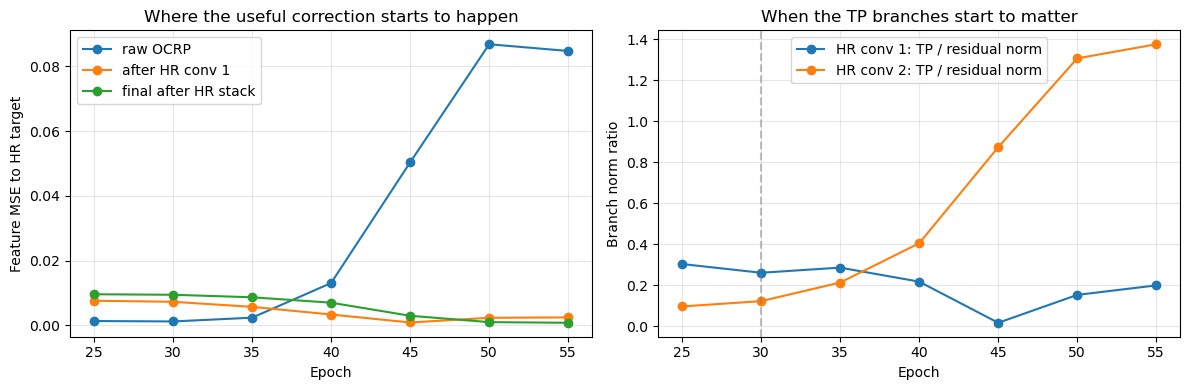

In [18]:
epoch_x = [int(r['epoch']) if r['epoch'] != 'best' else int(CHECKPOINT_LABELS[-2]) + 5 for r in sweep]
raw_y = [r['raw_mse'] for r in sweep]
conv1_y = [r['conv1_mse'] for r in sweep]
full_y = [r['full_mse'] for r in sweep]
tp1_ratio = [r['tp1_over_resid1'] for r in sweep]
tp2_ratio = [0.0 if r['tp2_over_resid2'] is None else r['tp2_over_resid2'] for r in sweep]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epoch_x, raw_y, marker='o', label='raw OCRP')
axes[0].plot(epoch_x, conv1_y, marker='o', label='after HR conv 1')
axes[0].plot(epoch_x, full_y, marker='o', label='final after HR stack')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Feature MSE to HR target')
axes[0].set_title('Where the useful correction starts to happen')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epoch_x, tp1_ratio, marker='o', label='HR conv 1: TP / residual norm')
axes[1].plot(epoch_x, tp2_ratio, marker='o', label='HR conv 2: TP / residual norm')
axes[1].axvline(30, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Branch norm ratio')
axes[1].set_title('When the TP branches start to matter')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## How to Read the Epoch-30 Bend

If the sweep shows the pattern we observed in terminal analysis, the story is:

1. **Early stage**
   - OCRP raw output is already the best approximation.
   - HR conv stages are weak or even harmful.
   - The network is mostly learning a stable OCRP representation with residual-dominated refinement.

2. **Around epoch 30**
   - The HR stack starts to become useful.
   - TP/residual ratios begin to rise.
   - The model starts to learn a division of labor instead of asking OCRP to be the final answer by itself.

3. **Later stage**
   - Raw OCRP may actually become *less* target-like by itself.
   - But the post-HR-conv output becomes better.
   - That means the network has become a **co-adapted two-stage system**:
     - OCRP produces features that are easier for the HR stack to refine
     - the HR stack does more of the final shaping

This is important: a bend in the total loss does **not** automatically mean the HR branch suddenly learned “smoothing.” It can mean the whole network changed regime and started relying on the HR stack for final correction.


## Why the HR Conv Is Not Automatically a Smoother

Even though it has neighborhood pooling, the HR conv is not initialized as a local average layer.

It starts from:
- `out = TP(center, neigh) + beta * center`

not from:
- `out = center + alpha * (neigh - center)`

That means:
- the TP branch is a general equivariant bilinear transform, not an explicit smoothing blend
- the residual path makes optimization easy by preserving a valid feature signal
- the easiest learned solution can be a small subtractive or rescaling correction rather than seam-smoothing

So if you want a branch that smooths from the start, the architecture needs a stronger smoothing prior than “TP + residual” by itself.


## Residual Path: What It Actually Does

The residual path is not just a shortcut for convenience. In practice it does three things:

1. **Stabilizes optimization**
   - The model does not need to discover identity-preserving TP behavior just to avoid damaging the feature.

2. **Anchors the feature manifold**
   - OCRP features already live in a decodable representation space.
   - The skip path keeps the HR conv from wandering too far off-manifold early.

3. **Changes what the TP branch learns**
   - With residual on, TP can learn a small correction.
   - With residual off, TP has to preserve the whole representation and refine it at the same time.
   - That is much harder.

This is why small positive residual weights can still train well, while `0.0` can collapse or become noisy.


## Link Back to the A1 TP Notebook Intuition

In the `A1_TensorProduct_Exploration` notebook, the self-TP case taught an important lesson:
- even when TP can represent a useful operation, the easiest learned behavior can be to scale or reweight an existing signal rather than invent a new transformation.

That same intuition shows up here:
- if `neigh` is already almost aligned with `center`, then `TP(center, neigh)` often behaves more like a learned rescaling/correction than a strong smoothing operator
- the residual path then becomes the dominant carrier of the final feature direction


## Practical Takeaways

For this HR conv design:
- **Residual on** usually helps learning rather than blocking it.
- **Context pooling** is real, but if the pooled context stays nearly colinear with the center, the TP branch may not become a strong smoother.
- A bend in the loss curve can mark the point where the network starts using the HR conv stack meaningfully, not necessarily the point where it starts smoothing.

If the actual goal is “smoothing first, refinement second,” the cleaner design would be:
- explicit `center/neigh` blend
- then TP refinement on top
- optionally plus a same-grain smoothness loss


## Reference: Saved Training Loss Curves

This is the saved loss-curve figure from the experiment itself:
- `experiments/IN718/iso_embedding_ocrp_01_4x4/visualizations/loss_curves.png`

It is useful to keep this visible while reading the checkpoint sweep above, because the bend near epoch 30 is what motivated the decomposition analysis in this notebook.


/data/home/umang/Materials/Reynolds-QSR_4x1/experiments/IN718/iso_embedding_ocrp_01_4x4/visualizations/loss_curves.png


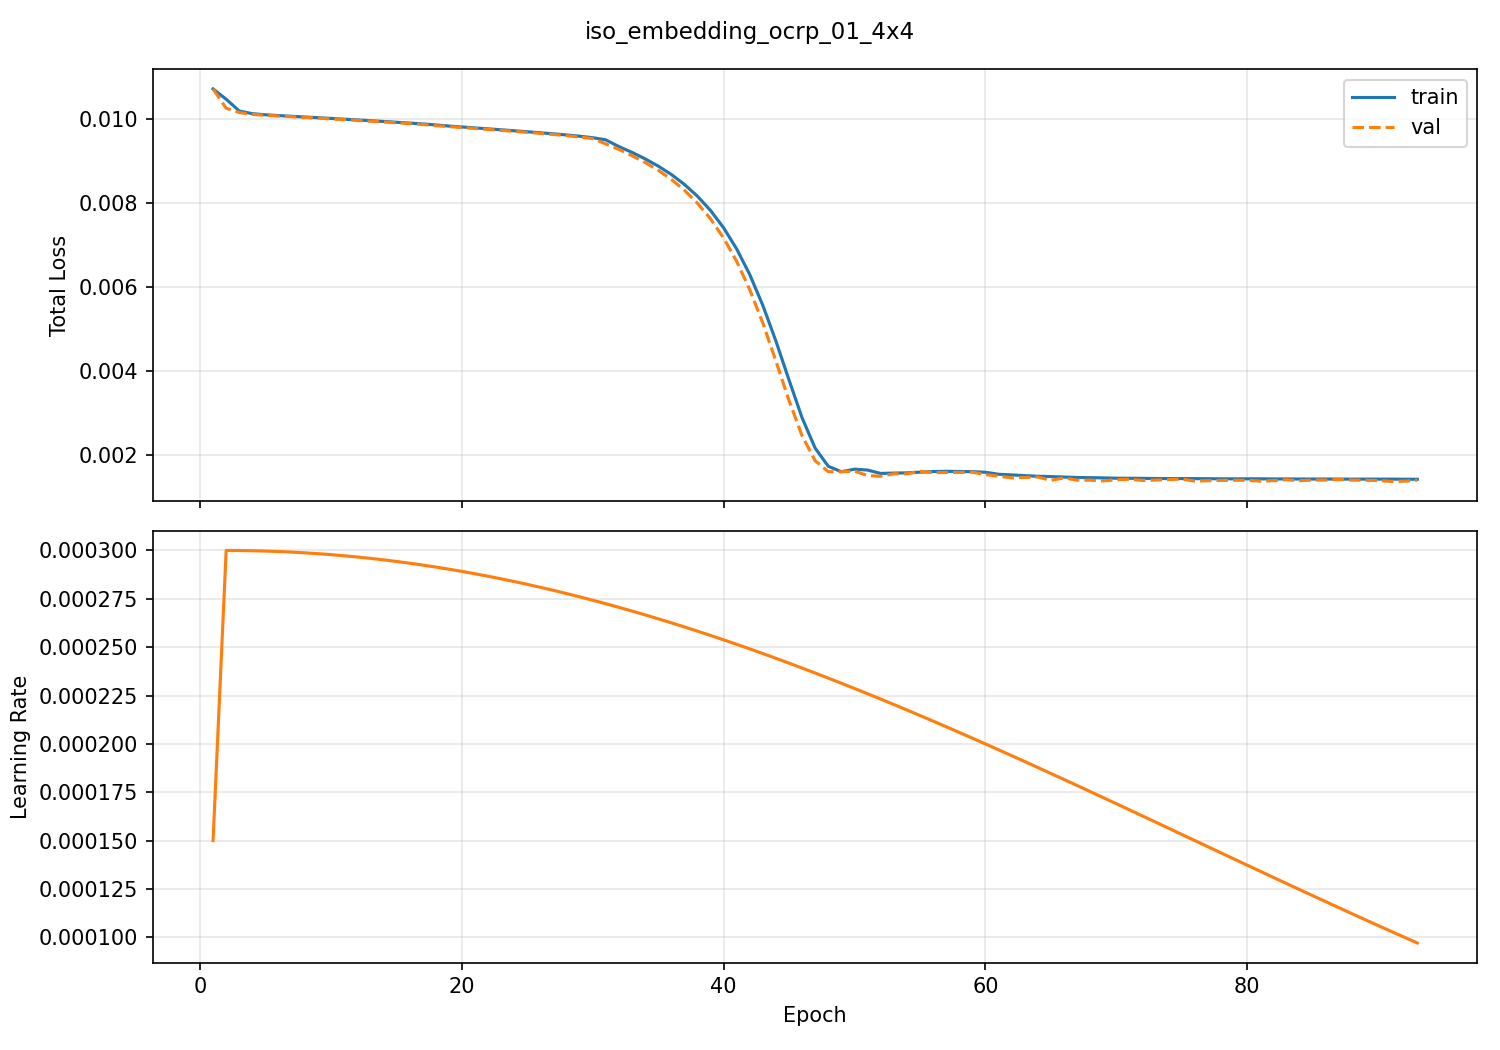

In [19]:
from IPython.display import Image, display

loss_curve_path = REPO_ROOT / 'experiments' / 'IN718' / 'iso_embedding_ocrp_01_4x4' / 'visualizations' / 'loss_curves.png'
print(loss_curve_path)
display(Image(filename=str(loss_curve_path)))
